In [46]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [47]:
# Load Kaggle dataset
df = pd.read_csv("diabetes.csv")


In [48]:
# 3. Display the First Five Rows of the Dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [49]:
# Check the Dataset Dimensions
print("Shape of dataset:", df.shape)

Shape of dataset: (768, 9)


In [50]:
#Display Feature and Target Column Names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [51]:
#Inspect Dataset Information
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [52]:
#Generate Statistical Summary
print("\nStatistical summary:")
df.describe()


Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [53]:
#Check for Missing Values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [54]:
#Identify Invalid Zero Values
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in zero_columns:
    print(column, ":", (df[column] == 0).sum())

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


In [55]:
#Replace Invalid Zeros with Missing Values
df_clean = df.copy()

for column in zero_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Invalid zeros replaced with NaN.")

Invalid zeros replaced with NaN.


In [56]:
print("Missing values after replacing invalid zeros:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [57]:
#Separate Input Features and Target Variable
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print("0 = No Diabetes")
print("1 = Diabetes")

Input features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
0 = No Diabetes
1 = Diabetes


In [58]:
# Split the Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [59]:
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(768, 8)
(768,)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [16]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [17]:
print("Input features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Input features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


In [60]:
# Handle Missing Values Using Median Imputation
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Median imputation completed.")

Median imputation completed.


In [61]:
# Apply StandardScaler to the Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed.")

Feature scaling completed.


In [62]:
# Train the Balanced Logistic Regression Model
model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [63]:
# Generate Predictions on the Test Data
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[1 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 1 0]


In [64]:
# Calculate Prediction Probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 diabetes probabilities:")
print(y_prob[:10])

First 10 diabetes probabilities:
[0.57714997 0.11023962 0.56912386 0.50635624 0.05137902 0.16595996
 0.72322199 0.94906424 0.10664725 0.95801597]


In [65]:
# Evaluate Model Performance Using Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== EVALUATION METRICS =====")
print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"ROC-AUC   : {roc_auc:.3f}")

===== EVALUATION METRICS =====
Accuracy  : 0.747
Precision : 0.609
Recall    : 0.778
F1-score  : 0.683
ROC-AUC   : 0.827


In [66]:
# Generate Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

              precision    recall  f1-score   support

 No Diabetes       0.86      0.73      0.79       100
    Diabetes       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154



In [67]:
#Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[73 27]
 [12 42]]


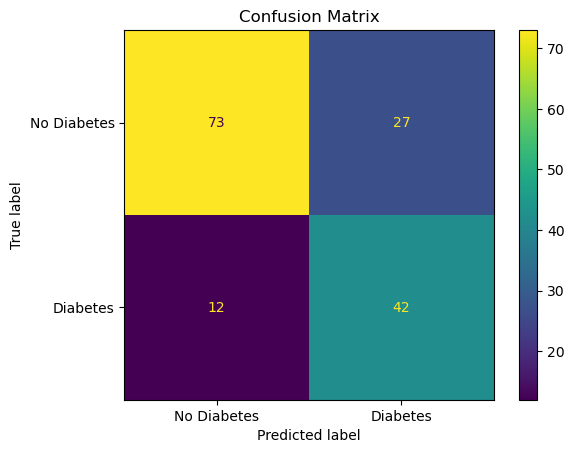

In [68]:
#Visualize the Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

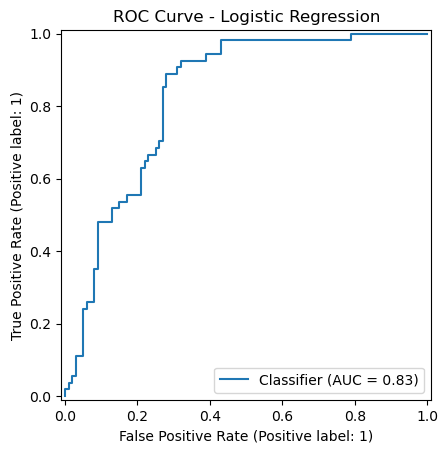

In [69]:
# Plot the ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [70]:
# Interpret Logistic Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                    Feature  Coefficient
1                   Glucose     0.904388
4                   Insulin     0.849074
5                       BMI     0.473949
0               Pregnancies     0.318641
3             SkinThickness     0.277745
6  DiabetesPedigreeFunction     0.227935
7                       Age     0.164487
2             BloodPressure     0.023701


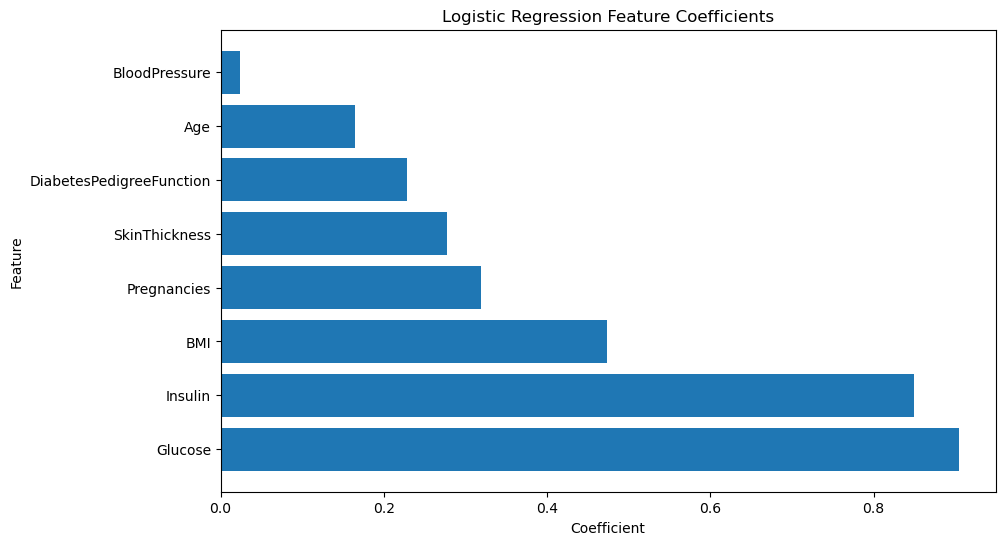

In [71]:
# Visualize Logistic Regression Feature Coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")

plt.show()

In [72]:
# Summary of Evaluation Metrics
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Result": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Result
0,Accuracy,0.746753
1,Precision,0.608696
2,Recall,0.777778
3,F1-score,0.682927
4,ROC-AUC,0.827222
